In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

D:\PROJECTS\Image_to_Biomass


In [2]:
from src.utils.trainer import train_one_epoch
from src.utils.metrics import calculate_metrics
from src.utils.early_stopping import EarlyStopping

print("All imports successful")

All imports successful


In [3]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

Using Device: cpu


In [4]:
from src.data.dataloader import get_dataloaders

train_loader, val_loader = get_dataloaders()

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 15
Validation batches: 4


Initialize the model

In [5]:
from src.models.biomass_model import BiomassModel

model = BiomassModel().to(device)

print(model)

BiomassModel(
  (feature_extractor): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNo

Loss function and optimizers

In [6]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

Early stopping

In [7]:
from src.utils.early_stopping import EarlyStopping

early_stopping = EarlyStopping(
    patience=5
)

Training here 

In [8]:
from src.utils.trainer import (
    train_one_epoch,
    validate_one_epoch
)

NUM_EPOCHS = 30

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )

    early_stopping(
        val_loss,
        model
    )

    if early_stopping.early_stop:

        print("Early stopping triggered.")

        break

100%|██████████| 15/15 [00:31<00:00,  2.13s/it]


Epoch [1/30] Train Loss: 1285.8106 | Validation Loss: 1279.5960


100%|██████████| 15/15 [00:31<00:00,  2.12s/it]


Epoch [2/30] Train Loss: 1234.0963 | Validation Loss: 1128.6050


100%|██████████| 15/15 [00:31<00:00,  2.13s/it]


...

Epoch [23/30] Train Loss: 224.4606 | Validation Loss: 258.5292
EarlyStopping Counter: 3/5


100%|██████████| 15/15 [00:31<00:00,  2.11s/it]


Epoch [24/30] Train Loss: 182.7509 | Validation Loss: 238.5778
EarlyStopping Counter: 4/5


100%|██████████| 15/15 [00:31<00:00,  2.10s/it]


Epoch [25/30] Train Loss: 203.6723 | Validation Loss: 264.2096
EarlyStopping Counter: 5/5
Early stopping triggered.


In [10]:
from pathlib import Path
import json

PROJECT_ROOT = Path("..").resolve()

history = {
    "train_loss": train_losses,
    "val_loss": val_losses
}

history_path = PROJECT_ROOT / "models" / "training_history.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print(f"Saved history to: {history_path}")

Saved history to: D:\PROJECTS\Image_to_Biomass\models\training_history.json


Saving the loss curve 

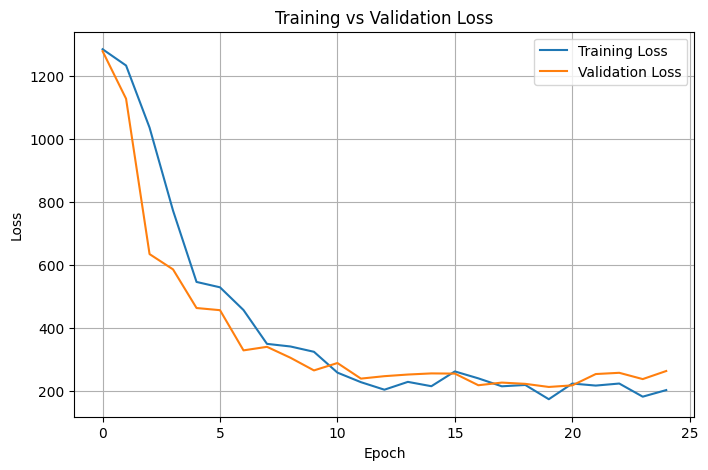

Saved plot to: D:\PROJECTS\Image_to_Biomass\outputs\plots\loss_curve.png


In [11]:
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

plots_dir = PROJECT_ROOT / "outputs" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plot_path = plots_dir / "loss_curve.png"

plt.savefig(plot_path, dpi=300)

plt.show()

print(f"Saved plot to: {plot_path}")